# EDA & Validation on Cleaned Datasets (Pre-Phase 11)

This notebook performs comprehensive validation of the **fixed canonical outputs**:
- `../data/cleaned/twcs_cleaned_fixed.csv`
- `../data/cleaned/questions_for_ml_fixed.csv`
- `../data/labeled/labeled_questions_fixed.csv`

Goal: confidently confirm datasets are ready for Phase 11 feature engineering.

In [1]:
# ============================================================
# SETUP
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
PLOT_COLOR = "#1f77b4"

TWCS_CLEANED = Path("../data/cleaned/twcs_cleaned_fixed.csv")
QUESTIONS_ML = Path("../data/cleaned/questions_for_ml_fixed.csv")
LABELED_Q = Path("../data/labeled/labeled_questions_fixed.csv")
PLOTS_DIR = Path("../logs/eda_cleaned_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

for p in [TWCS_CLEANED, QUESTIONS_ML, LABELED_Q]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p.resolve()}")

print("=" * 80)
print("EDA & VALIDATION - CLEANED DATASETS")
print("=" * 80)
print("✅ Required files found.")
print(f"Plot output dir: {PLOTS_DIR.resolve()}")

EDA & VALIDATION - CLEANED DATASETS
✅ Required files found.
Plot output dir: C:\projects\decision-assistant\logs\eda_cleaned_plots


In [4]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

EXPECTED_ROWS = {
    "twcs_cleaned": 2_811_774,
    "questions_for_ml": 1_537_843,
    "labeled_questions": 1_537_843,
}

checks = []

def add_check(name, ok, details=""):
    checks.append({"check": name, "passed": bool(ok), "details": details})
    icon = "✅" if ok else "❌"
    msg = f"{icon} {name}"
    if details:
        msg += f" | {details}"
    print(msg)

def count_rows_fast(path: Path) -> int:
    # Robust against embedded newlines in quoted CSV text.
    total = 0
    for ch in pd.read_csv(path, usecols=[0], chunksize=250_000, low_memory=False):
        total += len(ch)
    return int(total)

def profile_missing_chunked(path: Path, chunksize=250_000):
    total = 0
    na_counts = None
    blank_counts = None

    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        total += len(chunk)
        if na_counts is None:
            na_counts = pd.Series(0, index=chunk.columns, dtype="int64")
            blank_counts = pd.Series(0, index=chunk.columns, dtype="int64")

        na_counts = na_counts.add(chunk.isna().sum().astype("int64"), fill_value=0)

        for col in chunk.columns:
            s = chunk[col]
            if s.dtype == object or pd.api.types.is_string_dtype(s):
                blank_counts[col] += s.fillna("").astype(str).str.strip().eq("").sum()

    out = pd.DataFrame({
        "na_count": na_counts.astype(int),
        "na_pct": (na_counts / total * 100).round(4),
        "blank_count": blank_counts.astype(int),
        "blank_pct": (blank_counts / total * 100).round(4),
    }).sort_values(["na_count", "blank_count"], ascending=False)
    return out, total

print("✅ Helper functions initialized.")

✅ Helper functions initialized.


## Section 1 - Data Integrity Checks

Potential issues checked:
- Row-count mismatches (partial exports, accidental filtering)
- Nulls/blanks left after cleaning
- Duplicates from joins/appends
- Wrong dtypes causing downstream feature errors

Why this matters: Feature engineering and model training rely on schema stability and consistent row lineage.

In [5]:
# ============================================================
# SECTION 1.1 - Row counts
# ============================================================

row_counts = {
    "twcs_cleaned": count_rows_fast(TWCS_CLEANED),
    "questions_for_ml": count_rows_fast(QUESTIONS_ML),
    "labeled_questions": count_rows_fast(LABELED_Q),
}

row_df = pd.DataFrame({
    "dataset": row_counts.keys(),
    "actual_rows": row_counts.values(),
    "expected_rows": [EXPECTED_ROWS[k] for k in row_counts.keys()],
})
row_df["match"] = row_df["actual_rows"] == row_df["expected_rows"]
display(row_df)

for _, r in row_df.iterrows():
    add_check(
        f"Row count matches for {r['dataset']}",
        bool(r["match"]),
        f"actual={r['actual_rows']:,}, expected={r['expected_rows']:,}",
    )

,dataset,actual_rows,expected_rows,match
0,twcs_cleaned,2811774,2811774,True
1,questions_for_ml,1537843,1537843,True
2,labeled_questions,1537843,1537843,True


✅ Row count matches for twcs_cleaned | actual=2,811,774, expected=2,811,774
✅ Row count matches for questions_for_ml | actual=1,537,843, expected=1,537,843
✅ Row count matches for labeled_questions | actual=1,537,843, expected=1,537,843


In [6]:
# ============================================================
# SECTION 1.2 - Missing values (chunked, full datasets)
# ============================================================

mv_twcs, n_twcs = profile_missing_chunked(TWCS_CLEANED)
mv_qml, n_qml = profile_missing_chunked(QUESTIONS_ML)
mv_lab, n_lab = profile_missing_chunked(LABELED_Q)

print("twcs_cleaned missing profile (top 20):")
display(mv_twcs.head(20))
print("questions_for_ml missing profile:")
display(mv_qml)
print("labeled_questions missing profile:")
display(mv_lab)

add_check(
    "No NA values in questions_for_ml",
    int(mv_qml['na_count'].sum()) == 0,
    f"total_na={int(mv_qml['na_count'].sum()):,}",
)
add_check(
    "No NA values in labeled_questions",
    int(mv_lab['na_count'].sum()) == 0,
    f"total_na={int(mv_lab['na_count'].sum()):,}",
)
add_check(
    "No blank strings in text_for_ml (twcs_cleaned)",
    int(mv_twcs.loc['text_for_ml', 'blank_count']) == 0,
    f"blank_count={int(mv_twcs.loc['text_for_ml', 'blank_count']):,}",
)

twcs_cleaned missing profile (top 20):


,na_count,na_pct,blank_count,blank_pct
response_tweet_ids,2694140,95.8164,2694140,95.8164
parent_tweet_id,1065574,37.8969,0,0.0000
response_tweet_id,1040629,37.0097,1040629,37.0097
in_response_to_tweet_id,794335,28.2503,0,0.0000
text_for_rag,6,0.0002,6,0.0002
text_for_ml,1,0.0000,1,0.0000
tweet_id,0,0.0000,0,0.0000
conversation_id,0,0.0000,0,0.0000
position_in_conversation,0,0.0000,0,0.0000
total_tweets_in_conversation,0,0.0000,0,0.0000


questions_for_ml missing profile:


,na_count,na_pct,blank_count,blank_pct
question_text_for_ml,1,0.0001,1,0.0001
question_id,0,0.0000,0,0.0000
conversation_id,0,0.0000,0,0.0000
author_id,0,0.0000,0,0.0000
created_at,0,0.0000,0,0.0000


labeled_questions missing profile:


,na_count,na_pct,blank_count,blank_pct
question_text_for_ml,1,0.0001,1,0.0001
question_id,0,0.0000,0,0.0000
conversation_id,0,0.0000,0,0.0000
author_id,0,0.0000,0,0.0000
created_at,0,0.0000,0,0.0000
priority,0,0.0000,0,0.0000


❌ No NA values in questions_for_ml | total_na=1
❌ No NA values in labeled_questions | total_na=1
❌ No blank strings in text_for_ml (twcs_cleaned) | blank_count=1


In [7]:
# ============================================================
# SECTION 1.3 - Duplicate checks
# ============================================================

twcs_head = pd.read_csv(TWCS_CLEANED, usecols=['tweet_id'], low_memory=False)
dup_tweet = int(twcs_head['tweet_id'].duplicated().sum())
add_check("tweet_id unique in twcs_cleaned", dup_tweet == 0, f"duplicates={dup_tweet:,}")

qml = pd.read_csv(QUESTIONS_ML, low_memory=False)
dup_qid = int(qml['question_id'].duplicated().sum())
dup_exact_qml = int(qml.duplicated().sum())
add_check("question_id unique in questions_for_ml", dup_qid == 0, f"duplicates={dup_qid:,}")
add_check("No exact duplicate rows in questions_for_ml", dup_exact_qml == 0, f"duplicates={dup_exact_qml:,}")

lab = pd.read_csv(LABELED_Q, low_memory=False)
dup_qid_lab = int(lab['question_id'].duplicated().sum())
dup_exact_lab = int(lab.duplicated().sum())
add_check("question_id unique in labeled_questions", dup_qid_lab == 0, f"duplicates={dup_qid_lab:,}")
add_check("No exact duplicate rows in labeled_questions", dup_exact_lab == 0, f"duplicates={dup_exact_lab:,}")

✅ tweet_id unique in twcs_cleaned | duplicates=0
✅ question_id unique in questions_for_ml | duplicates=0
✅ No exact duplicate rows in questions_for_ml | duplicates=0
✅ question_id unique in labeled_questions | duplicates=0
✅ No exact duplicate rows in labeled_questions | duplicates=0


In [8]:
# ============================================================
# SECTION 1.4 - Dtype checks
# ============================================================

twcs = pd.read_csv(TWCS_CLEANED, low_memory=False)
print("twcs_cleaned dtypes:")
display(twcs.dtypes.sort_index())

expected_present = {
    'tweet_id', 'conversation_id', 'position_in_conversation',
    'inbound', 'is_question', 'created_at',
    'text_original', 'text_for_rag', 'text_for_ml'
}
missing_expected = expected_present - set(twcs.columns)
add_check("Expected key columns exist in twcs_cleaned", len(missing_expected) == 0, f"missing={sorted(missing_expected)}")

add_check("tweet_id is numeric", pd.api.types.is_numeric_dtype(twcs['tweet_id']))
add_check("conversation_id is numeric", pd.api.types.is_numeric_dtype(twcs['conversation_id']))
add_check("position_in_conversation is numeric", pd.api.types.is_numeric_dtype(twcs['position_in_conversation']))
add_check("inbound is boolean-like", twcs['inbound'].dropna().isin([True, False]).all())
add_check("is_question is boolean-like", twcs['is_question'].dropna().isin([True, False]).all())

twcs_cleaned dtypes:


author_id                           str
conversation_id                   int64
created_at                          str
has_response                       bool
in_response_to_tweet_id         float64
inbound                            bool
is_question                        bool
parent_tweet_id                 float64
position_in_conversation          int64
response_tweet_id                   str
response_tweet_ids                  str
text                                str
text_for_ml                         str
text_for_rag                        str
text_original                       str
total_tweets_in_conversation      int64
tweet_id                          int64
dtype: object

✅ Expected key columns exist in twcs_cleaned | missing=[]
✅ tweet_id is numeric
✅ conversation_id is numeric
✅ position_in_conversation is numeric
✅ inbound is boolean-like
✅ is_question is boolean-like


## Section 1 Explanation

- Earlier phases intentionally preserved all rows in the full cleaned table.
- Missing-value strategy for text used placeholders (`[EMPTY]`) instead of dropping rows.
- Duplicate checks focus on ID uniqueness and exact-row duplication to catch accidental data inflation.

## Section 1.5 - Text Cleaning Verification

Potential issues checked:
- `@mentions` remaining in model/retrieval text
- URL residues harming similarity/model quality
- emoji/uppercase leakage in ML text
- accidental mutation of original text

In [9]:
url_probe = r"(?:https?://|t\.co/|\bwww\.)"
mention_probe = r"(?:^|[\s\n])@\w"
emoji_probe = r"[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U000024C2-\U0001F251]"

rag = twcs['text_for_rag'].fillna('').astype(str)
ml = twcs['text_for_ml'].fillna('').astype(str)
orig = twcs['text_original'].fillna('').astype(str)

rag_mentions = int(rag.str.contains(mention_probe, regex=True, na=False).sum())
ml_mentions = int(ml.str.contains(mention_probe, regex=True, na=False).sum())
rag_urls = int(rag.str.contains(url_probe, case=False, regex=True, na=False).sum())
ml_urls = int(ml.str.contains(url_probe, case=False, regex=True, na=False).sum())
ml_emojis = int(ml.str.contains(emoji_probe, regex=True, na=False).sum())
ml_upper = int(ml[ml != '[EMPTY]'].str.contains(r"[A-Z]", regex=True, na=False).sum())

case_preserved_examples = int((rag != rag.str.lower()).sum())
orig_diff_count = int((orig != twcs['text'].fillna('').astype(str)).sum()) if 'text' in twcs.columns else 0

add_check("No @mentions in text_for_rag", rag_mentions == 0, f"count={rag_mentions:,}")
add_check("No @mentions in text_for_ml", ml_mentions == 0, f"count={ml_mentions:,}")
add_check("No URLs in text_for_rag", rag_urls == 0, f"count={rag_urls:,}")
add_check("No URLs in text_for_ml", ml_urls == 0, f"count={ml_urls:,}")
add_check("No emojis in text_for_ml", ml_emojis == 0, f"count={ml_emojis:,}")
add_check("text_for_ml lowercase (except [EMPTY])", ml_upper == 0, f"uppercase_rows={ml_upper:,}")
add_check("text_for_rag preserves case signal", case_preserved_examples > 0, f"mixed_case_rows={case_preserved_examples:,}")

if 'text' in twcs.columns:
    add_check("text_original equals source text", orig_diff_count == 0, f"diff_rows={orig_diff_count:,}")

✅ No @mentions in text_for_rag | count=0
✅ No @mentions in text_for_ml | count=0
✅ No URLs in text_for_rag | count=0
✅ No URLs in text_for_ml | count=0
✅ No emojis in text_for_ml | count=0
✅ text_for_ml lowercase (except [EMPTY]) | uppercase_rows=0
✅ text_for_rag preserves case signal | mixed_case_rows=2,665,815
✅ text_original equals source text | diff_rows=0


## Section 2 - Conversation Structure Validation

Potential issues checked:
- broken sequence positions in conversations
- inconsistent `total_tweets_in_conversation`
- broken parent/child references
- mismatch between inbound and question flags

In [10]:
# ============================================================
# SECTION 2.1 - Position and conversation consistency
# ============================================================

grp = twcs.groupby('conversation_id', sort=False)['position_in_conversation']
max_pos = grp.max()
min_pos = grp.min()
n_rows = grp.size()

seq_ok = ((min_pos == 1) & (max_pos == n_rows)).all()
add_check("Conversation positions start at 1 and end at N", bool(seq_ok))

if 'total_tweets_in_conversation' in twcs.columns:
    conv_totals = twcs.groupby('conversation_id')['total_tweets_in_conversation'].nunique()
    one_total_per_conv = (conv_totals == 1).all()
    add_check("Single total_tweets value per conversation", bool(one_total_per_conv))

    compare_totals = twcs.groupby('conversation_id').agg(
        total_col=('total_tweets_in_conversation', 'first'),
        max_pos=('position_in_conversation', 'max')
    )
    totals_match = (compare_totals['total_col'] == compare_totals['max_pos']).all()
    add_check("total_tweets_in_conversation matches max position", bool(totals_match))

✅ Conversation positions start at 1 and end at N
✅ Single total_tweets value per conversation
✅ total_tweets_in_conversation matches max position


In [11]:
# ============================================================
# SECTION 2.2 - Parent-child relationships
# ============================================================

tweet_ids = set(twcs['tweet_id'].astype(int).tolist())

if 'parent_tweet_id' in twcs.columns:
    parent = twcs['parent_tweet_id'].dropna().astype(int)
missing_parent_refs = int((~parent.isin(tweet_ids)).sum())
    
add_check("All parent_tweet_id references exist", missing_parent_refs == 0, f"missing_refs={missing_parent_refs:,}")

if 'has_response' in twcs.columns and 'response_tweet_ids' in twcs.columns:
    has_resp_from_ids = twcs['response_tweet_ids'].fillna('').astype(str).str.strip().ne('')
    mismatch = int((twcs['has_response'].astype(bool) != has_resp_from_ids).sum())
    add_check("has_response consistent with response_tweet_ids", mismatch == 0, f"mismatch_rows={mismatch:,}")

✅ All parent_tweet_id references exist | missing_refs=0
✅ has_response consistent with response_tweet_ids | mismatch_rows=0


In [12]:
# ============================================================
# SECTION 2.3 - Inbound/outbound balance and is_question
# ============================================================

inbound_counts = twcs['inbound'].value_counts(dropna=False)
print("Inbound/Outbound counts:")
print(inbound_counts.to_string())

if 'is_question' in twcs.columns:
    q_true = int((twcs['is_question'] == True).sum())
    inbound_true = int((twcs['inbound'] == True).sum())
    add_check("is_question count <= inbound count", q_true <= inbound_true, f"is_question={q_true:,}, inbound={inbound_true:,}")

Inbound/Outbound counts:
inbound
True     1537843
False    1273931
✅ is_question count <= inbound count | is_question=1,537,843, inbound=1,537,843


## Section 3 - Label Distribution Analysis

Potential issues checked:
- invalid priority values
- null labels
- class imbalance that may require mitigation in modeling

In [13]:
lab = pd.read_csv(LABELED_Q, low_memory=False)
prio = lab['priority']
vc = prio.value_counts(dropna=False)
pct = (vc / len(lab) * 100).round(2)
label_df = pd.DataFrame({'count': vc, 'pct': pct})
display(label_df)

valid_set = set(prio.dropna().unique())
add_check("Priority has only urgent/normal", valid_set <= {'urgent', 'normal'}, f"values={sorted(valid_set)}")
null_priority = int(prio.isna().sum())
add_check("No null priorities", null_priority == 0, f"nulls={null_priority:,}")

urgent_pct = float(pct.get('urgent', 0.0))
if urgent_pct < 10 or urgent_pct > 90:
    print(f"⚠️ Class imbalance warning: urgent={urgent_pct:.2f}%")
else:
    print(f"✅ Class ratio looks trainable: urgent={urgent_pct:.2f}%")

,count,pct
priority,,
normal,1087531,70.72
urgent,450312,29.28


✅ Priority has only urgent/normal | values=['normal', 'urgent']
✅ No null priorities | nulls=0
✅ Class ratio looks trainable: urgent=29.28%


## Section 4 - Statistical Summary

Potential issues checked:
- extreme ranges/outliers in text-derived numeric signals
- temporal coverage anomalies

In [14]:
sample_n = 300_000
eda = lab.sample(min(sample_n, len(lab)), random_state=RANDOM_STATE).copy()
txt = eda['question_text_for_ml'].fillna('').astype(str)

eda['char_count'] = txt.str.len()
eda['word_count'] = txt.str.split().str.len()
eda['exclamation_count'] = txt.str.count('!')
eda['question_count'] = txt.str.count(r'\?')
letters = txt.str.count(r'[a-zA-Z]')
caps = txt.str.count(r'[A-Z]')
eda['caps_ratio'] = np.where(letters > 0, caps / letters, 0.0)

num_cols = ['char_count', 'word_count', 'exclamation_count', 'question_count', 'caps_ratio']
desc = eda[num_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T
desc['skew'] = eda[num_cols].skew(numeric_only=True)
display(desc[['mean', '50%', '90%', '95%', '99%', 'max', 'skew']])

if 'created_at' in eda.columns:
    dt = pd.to_datetime(eda['created_at'], errors='coerce', utc=True)
    valid_dt = dt.notna().sum()
    print(f"Parsed created_at rows: {valid_dt:,} / {len(dt):,}")
    if valid_dt > 0:
        print(f"Date range: {dt.min()} -> {dt.max()}")

,mean,50%,90%,95%,99%,max,skew
char_count,92.321827,91.0,152.0,204.0,265.0,296.0,0.760626
word_count,17.265070,17.0,29.0,38.0,50.0,137.0,0.796818
exclamation_count,0.275160,0.0,1.0,2.0,4.0,153.0,23.200487
question_count,0.340517,0.0,1.0,2.0,3.0,140.0,26.475153
caps_ratio,0.012817,0.0,0.0,0.0,1.0,1.0,8.662398


C:\Users\Jawad\AppData\Local\Temp\ipykernel_3836\1868550503.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(eda['created_at'], errors='coerce', utc=True)


Parsed created_at rows: 300,000 / 300,000
Date range: 2011-06-16 13:38:36+00:00 -> 2017-12-03 23:12:12+00:00


## Section 5 - Visualizations

All plots are saved under `../logs/eda_cleaned_plots/`.

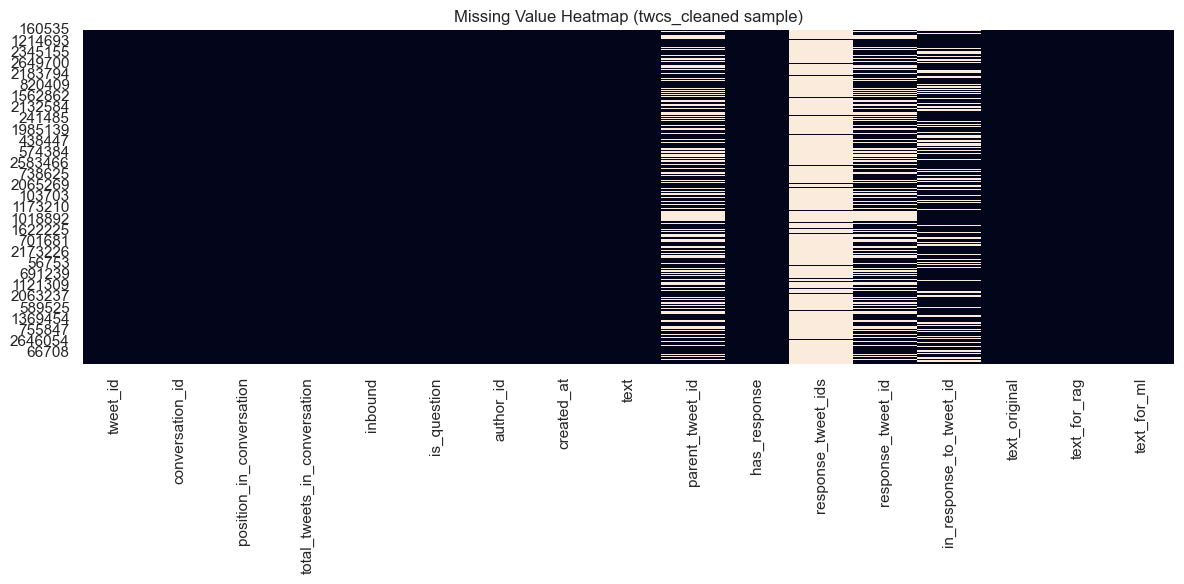

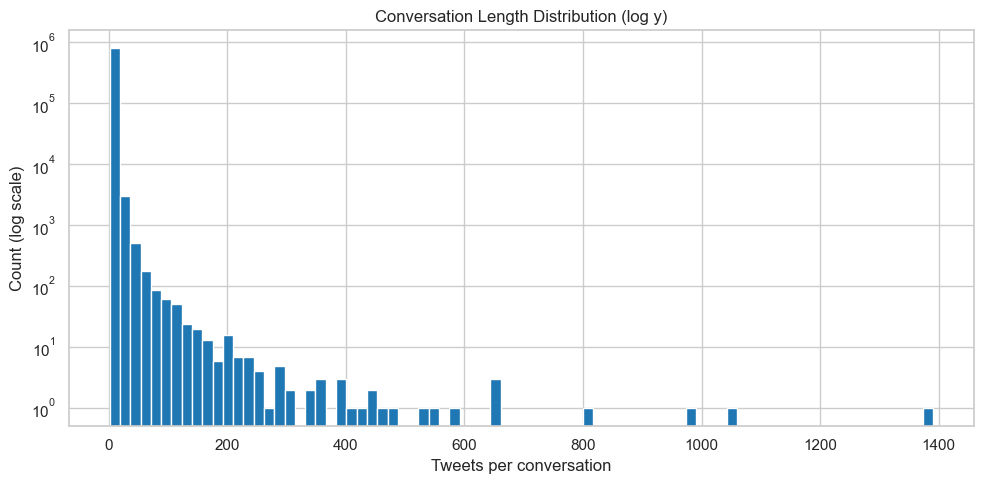

In [15]:
# 13) Missing value heatmap (sample)
heat_sample = twcs.sample(min(20_000, len(twcs)), random_state=RANDOM_STATE)
plt.figure(figsize=(12, 6))
sns.heatmap(heat_sample.isna(), cbar=False)
plt.title('Missing Value Heatmap (twcs_cleaned sample)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_missing_heatmap.png', dpi=160)
plt.show()

# 14) Conversation length histogram (log y)
conv_len = twcs.groupby('conversation_id').size()
plt.figure(figsize=(10, 5))
plt.hist(conv_len, bins=80, color=PLOT_COLOR, edgecolor='white')
plt.yscale('log')
plt.title('Conversation Length Distribution (log y)')
plt.xlabel('Tweets per conversation')
plt.ylabel('Count (log scale)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_conversation_length_log.png', dpi=160)
plt.show()

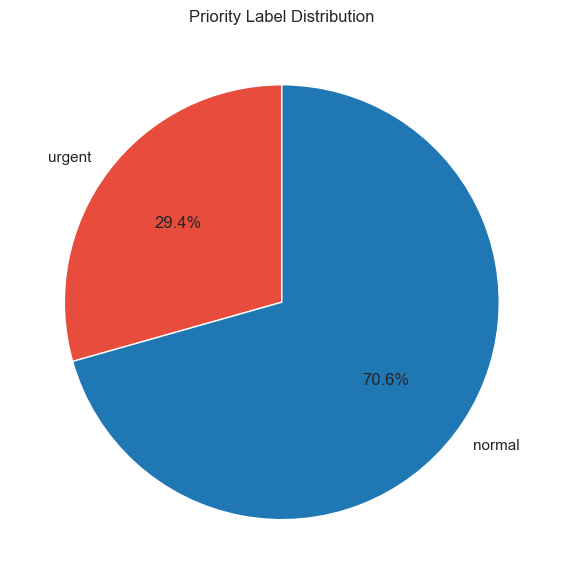

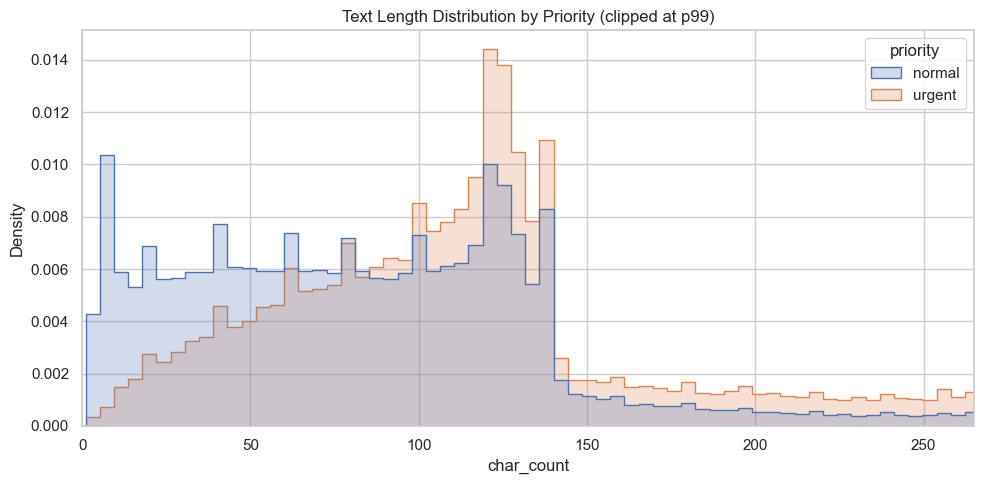

In [14]:
# 15) Priority label pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    [int(vc.get('urgent', 0)), int(vc.get('normal', 0))],
    labels=['urgent', 'normal'],
    autopct='%1.1f%%',
    colors=['#e74c3c', PLOT_COLOR],
    startangle=90,
)
plt.title('Priority Label Distribution')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_priority_pie.png', dpi=160)
plt.show()

# 16) Text length by priority
plt.figure(figsize=(10, 5))
sns.histplot(data=eda, x='char_count', hue='priority', bins=70, element='step', stat='density', common_norm=False)
plt.xlim(0, np.quantile(eda['char_count'], 0.99))
plt.title('Text Length Distribution by Priority (clipped at p99)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_text_length_by_priority.png', dpi=160)
plt.show()

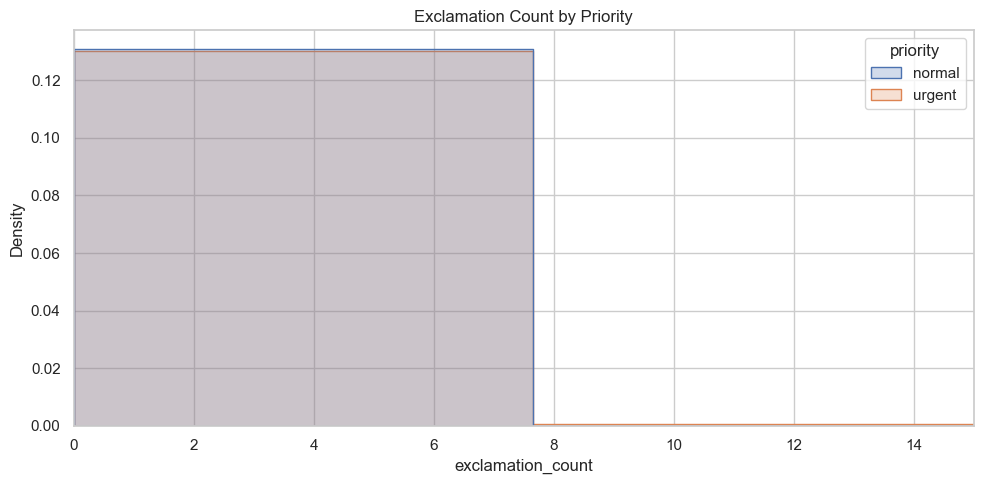

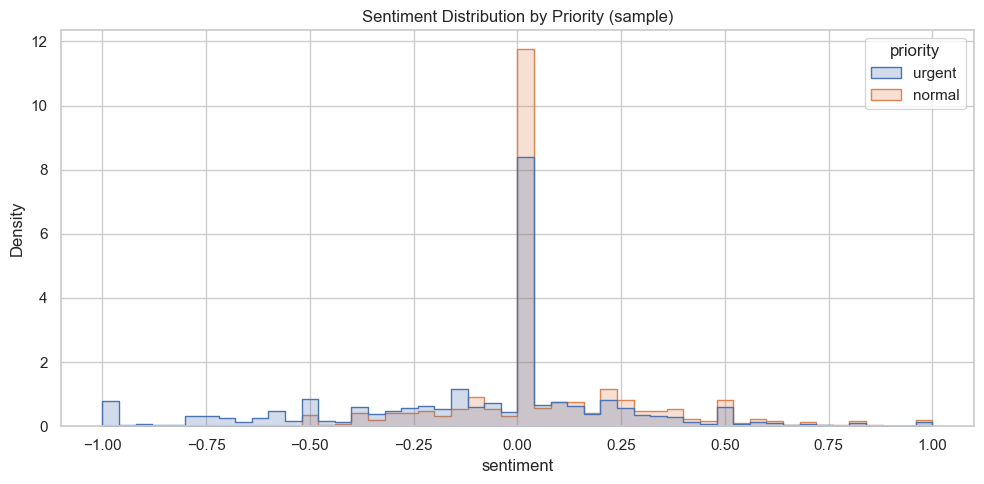

In [15]:
# 17) Exclamation count by priority
plt.figure(figsize=(10, 5))
sns.histplot(data=eda, x='exclamation_count', hue='priority', bins=20, element='step', stat='density', common_norm=False)
plt.xlim(0, min(15, int(eda['exclamation_count'].max())))
plt.title('Exclamation Count by Priority')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_exclamation_by_priority.png', dpi=160)
plt.show()

# 18) Sentiment distribution by priority (sample to keep runtime acceptable)
sent_sample = eda.sample(min(30_000, len(eda)), random_state=RANDOM_STATE).copy()
from textblob import TextBlob
sent_sample['sentiment'] = sent_sample['question_text_for_ml'].fillna('').astype(str).map(lambda t: TextBlob(t).sentiment.polarity)

plt.figure(figsize=(10, 5))
sns.histplot(data=sent_sample, x='sentiment', hue='priority', bins=50, element='step', stat='density', common_norm=False)
plt.title('Sentiment Distribution by Priority (sample)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '06_sentiment_by_priority.png', dpi=160)
plt.show()

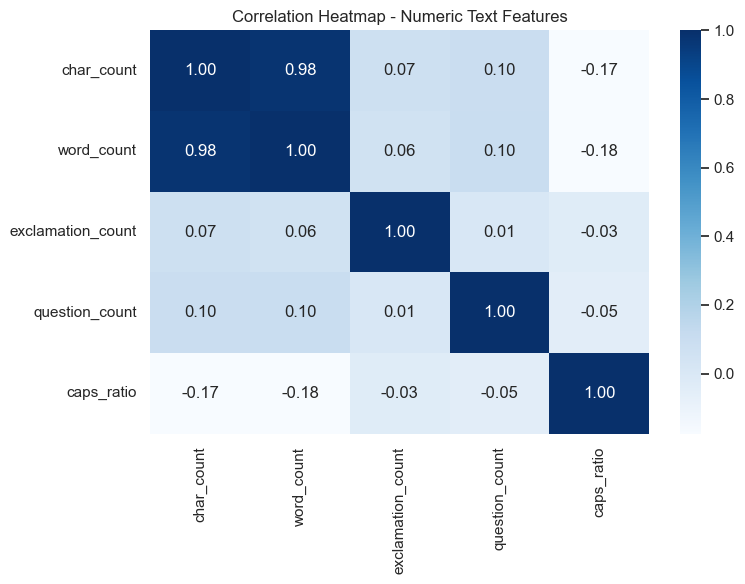

In [16]:
# 19) Correlation heatmap of numeric features
corr_cols = ['char_count', 'word_count', 'exclamation_count', 'question_count', 'caps_ratio']
corr = eda[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Text Features')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '07_correlation_heatmap.png', dpi=160)
plt.show()

## Section 6 - Data Quality Report

This final section aggregates all pass/fail checks and provides recommendations for Phase 11.

In [17]:
checks_df = pd.DataFrame(checks)
display(checks_df)

passed = int(checks_df['passed'].sum())
failed = int((~checks_df['passed']).sum())

print("=" * 80)
print("FINAL DATA QUALITY SUMMARY")
print("=" * 80)
print(f"Total checks: {len(checks_df):,}")
print(f"✅ Passed: {passed:,}")
print(f"❌ Failed: {failed:,}")

if failed == 0:
    print("\n✅ All datasets passed validation and are ready for Phase 11.")
else:
    print("\n⚠️ Some checks failed. Review failed rows in checks_df before Phase 11.")

print("\nRecommendations for Phase 11:")
print("1) Use stratified split on priority label.")
print("2) Consider log1p transforms for highly skewed count features in linear models.")
print("3) Keep tree-based models (RF/XGB) as robust baseline against skew/outliers.")
print(f"4) Review saved plots in: {PLOTS_DIR.resolve()}")

,check,passed,details
0,Row count matches for twcs_cleaned,True,"actual=2,811,774, expected=2,811,774"
1,Row count matches for questions_for_ml,True,"actual=1,537,843, expected=1,537,843"
2,Row count matches for labeled_questions,True,"actual=1,537,843, expected=1,537,843"
3,No NA values in questions_for_ml,False,total_na=1
4,No NA values in labeled_questions,False,total_na=1
5,No blank strings in text_for_ml (twcs_cleaned),False,blank_count=1
6,tweet_id unique in twcs_cleaned,True,duplicates=0
7,question_id unique in questions_for_ml,True,duplicates=0
8,No exact duplicate rows in questions_for_ml,True,duplicates=0
9,question_id unique in labeled_questions,True,duplicates=0


FINAL DATA QUALITY SUMMARY
Total checks: 33
✅ Passed: 30
❌ Failed: 3

⚠️ Some checks failed. Review failed rows in checks_df before Phase 11.

Recommendations for Phase 11:
1) Use stratified split on priority label.
2) Consider log1p transforms for highly skewed count features in linear models.
3) Keep tree-based models (RF/XGB) as robust baseline against skew/outliers.
4) Review saved plots in: C:\projects\decision-assistant\logs\eda_cleaned_plots
